
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [94]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

## Load Dataset

In [95]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/refs/heads/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


## Exploratory Data Analysis

In [96]:
# Check Type and info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [97]:
# Check missing values
print(df.isnull().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [98]:
# Check Duplicate values
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)
df = df.drop_duplicates()
df.count()

number of duplicate rows:  (127, 6)


,0
Hours Studied,9873
Previous Scores,9873
Extracurricular Activities,9873
Sleep Hours,9873
Sample Question Papers Practiced,9873
Performance Index,9873


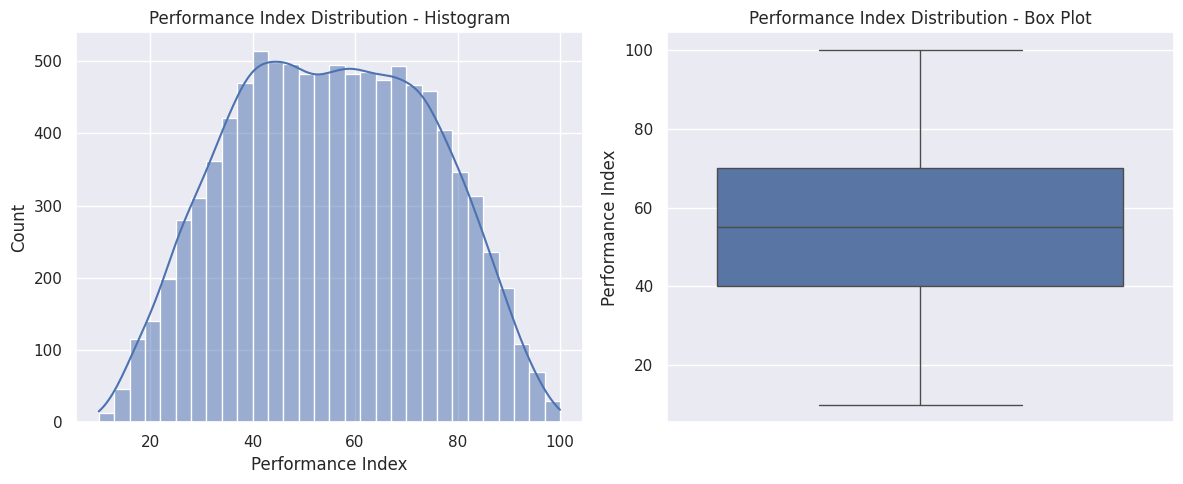

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [99]:
# Distibution Plot
# Visualizing the price distribution.

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance Index Distribution - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index Distribution - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [100]:
# Encode categorical columns if any
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Extracurricular Activities'
]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded_status = df_encoded.astype(int)
df1 = df_encoded_status.copy()
df1.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


## Visualization

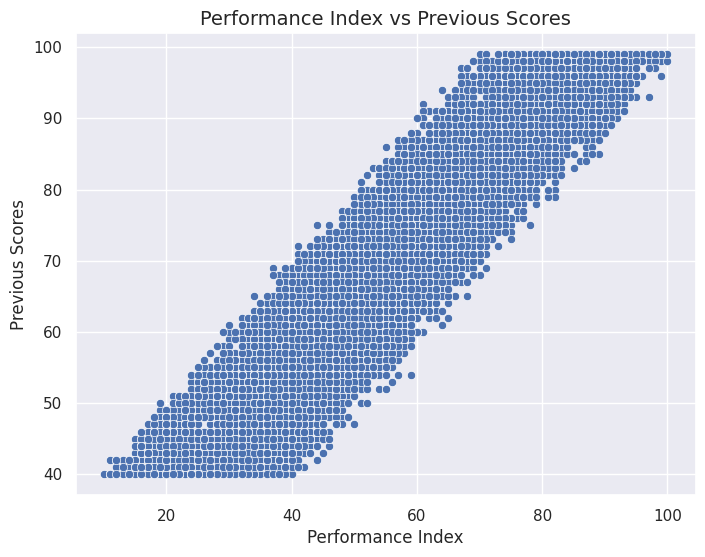

<Axes: >

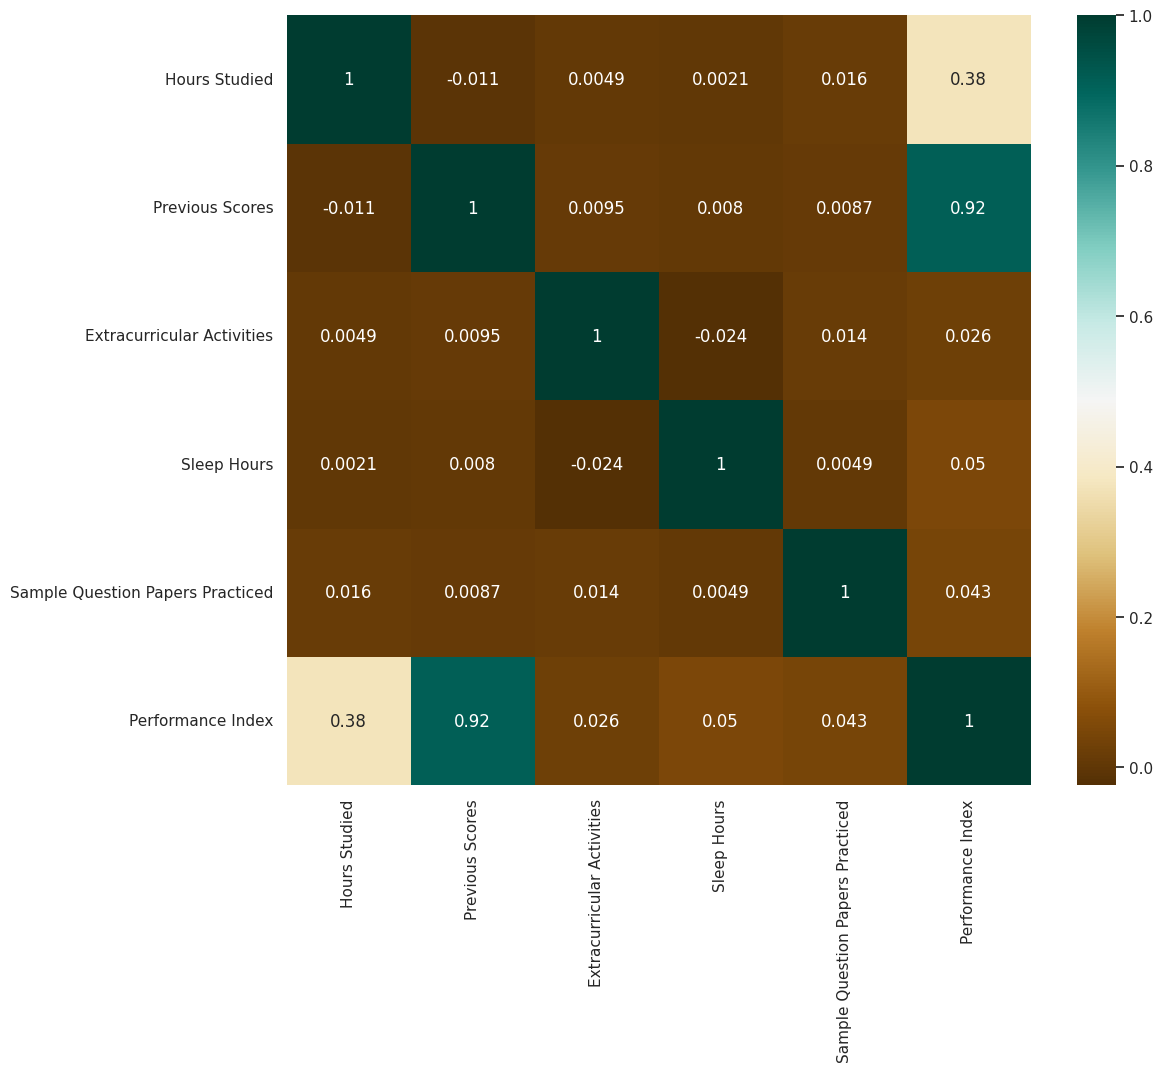

In [101]:
# Scatter plots
# Creating a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="Performance Index", y="Previous Scores", data=df1)
plt.title(f"Performance Index vs Previous Scores", fontsize=14)
plt.xlabel("Performance Index", fontsize=12)
plt.ylabel("Previous Scores", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Heatmap
c = df1.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="BrBG",annot=True)

## Correlation Analysis

In [102]:
# Compute correlation matrix
c   # Already Calculate it

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


## Feature Selection

In [103]:
df1 = df1.drop(['Extracurricular Activities','Sleep Hours', 'Sample Question Papers Practiced'], axis=1)
df1.head(5)


,Hours Studied,Previous Scores,Performance Index
0,7,99,91
1,4,82,65
2,8,51,45
3,5,52,36
4,7,75,66


## Train-Test Split

In [104]:
# Importing necessary libraries.
from sklearn.model_selection import train_test_split # For splitting the dataset.
from sklearn.preprocessing import MinMaxScaler # For Scaling the features.

X = df1.drop("Performance Index", axis=1)
y = df1["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Feature Scaling (If needed)

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# for SVR
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()



# Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import time

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
results = []

# Linear Regression

start_train = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
end_train = time.time()

start_test = time.time()
y_pred = lr.predict(X_test)
end_test = time.time()
# R-squared
r2 = r2_score(y_test, y_pred)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# MAE
mae = mean_absolute_error(y_test, y_pred)

print("LR Performance:")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

results.append(["Linear Regression", mae, rmse, r2,
                end_train - start_train,
                end_test - start_test])


#SVR
start_train = time.time()
svr = SVR()
svr.fit(x_train_scaled, y_train)
end_train = time.time()


start_test = time.time()
y_pred = svr.predict(x_test_scaled)
end_test = time.time()


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n\nSVR Performance:")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

results.append(["SVR", mae, rmse, r2,
                end_train - start_train,
                end_test - start_test])

# Decision Tree

start_train = time.time()
Decision_tree = DecisionTreeRegressor()
Decision_tree.fit(x_train_scaled, y_train)
end_train = time.time()

start_test = time.time()
y_pred = Decision_tree.predict(x_test_scaled)
end_test = time.time()


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

results.append(["Decision Tree", mae, rmse, r2,
                end_train - start_train,
                end_test - start_test])

print("\n\nDecision Tree Model Performance")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# Random Forest

start_train = time.time()
Random_Forest = RandomForestRegressor()
Random_Forest.fit(x_train_scaled, y_train)
end_train = time.time()

start_test = time.time()
y_pred = Random_Forest.predict(x_test_scaled)
end_test = time.time()


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

results.append(["Random Forest", mae, rmse, r2,
                end_train - start_train,
                end_test - start_test])

print("\n\nRandom Forest Model Performance")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

#KNN
start_train = time.time()
KNn = KNeighborsRegressor()
KNn.fit(x_train_scaled, y_train)
end_train = time.time()

start_test = time.time()
y_pred = KNn.predict(x_test_scaled)
end_test = time.time()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

results.append(["KNN", mae, rmse, r2,
                end_train - start_train,
                end_test - start_test])

print("\n\nRNN Model Performance")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


LR Performance:
R² Score: 0.9849836295403213
RMSE: 2.342319368359754
MAE: 1.8618474980442314


SVR Performance:
R² Score: 0.9842226573887777
RMSE: 2.400935819144611
MAE: 1.912411265676622


Decision Tree Model Performance
R² Score: 0.9840308018121167
RMSE: 2.4154896334609046
MAE: 1.913676020695559


Random Forest Model Performance
R² Score: 0.9840186890340522
RMSE: 2.416405544937433
MAE: 1.915151662069386


RNN Model Performance
R² Score: 0.9819766163535696
RMSE: 2.566148507667299
MAE: 2.032140445644835


### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?

Random Forest Regressor is an ensemble model that combines multiple decision tree regressors. Each tree is trained on a bootstrap sample of the data and uses random subsets of features at each split. Every tree predicts a continuous value, and the final prediction is obtained by averaging the outputs of all trees. This reduces variance and prevents overfitting compared to a single decision tree.






### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

KNN Regressor predicts a continuous value by finding the K closest data points to a new input based on a distance metric such as Euclidean distance. The value of K determines how many neighbors influence the prediction. The final predicted value is calculated as the average (or weighted average) of the target values of those K nearest neighbors. Because the method is distance-based, feature scaling is essential.

## Visualize Best Model

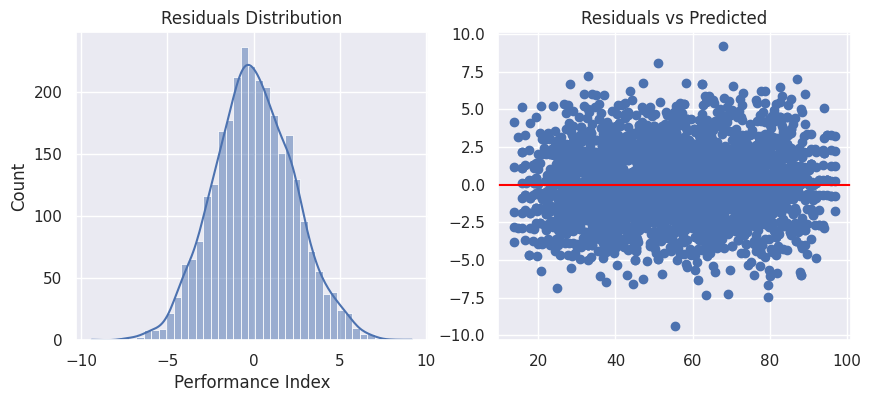

In [107]:
# Select best model based on R2
# Linear Regression had least R2
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

# Calculate residuals
residuals = y_test - y_pred


# Histogram of residuals
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")


# Residuals vs Predicted
plt.subplot(1,2,2)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")


plt.show()

## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [108]:
model_results = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R2 Score", "Training Time", "Testing Time"
])

model_results

,Model,MAE,RMSE,R2 Score,Training Time,Testing Time
0,Linear Regression,1.861847,2.342319,0.984984,0.005664,0.003674
1,SVR,1.912411,2.400936,0.984223,2.704265,2.008506
2,Decision Tree,1.913676,2.415490,0.984031,0.009065,0.001349
3,Random Forest,1.915444,2.416935,0.984012,0.599992,0.053770
4,KNN,2.032140,2.566149,0.981977,0.005247,0.009607
